# Conformal Prediction for Directed Graph Link Prediction on OGB Citation2

This notebook applies **split conformal prediction** to the **ogbl-citation2** dataset from the Open Graph Benchmark.

## Dataset: ogbl-citation2
- **Nodes**: 2,927,963 (academic papers)
- **Edges**: 30,561,187 (directed citations)
- **Task**: Predict missing citations between papers

## Key Methodology
1. **Directed SVD embeddings**: Separate source and target embeddings
2. **Mondrian conformal prediction**: Label-conditional coverage guarantees
3. **OGB-style edge splitting**: Message edges for representation, supervision edges for training

In [1]:
pip install ogb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 1.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import TruncatedSVD
import torch

# OGB for loading the dataset (non-PyG version)
from ogb.linkproppred import LinkPropPredDataset

RNG_SEED = 42
print("Imports ready.")

Imports ready.


## 1. Mathematical Foundations

### 1.1 Directed Graph Representation

A directed graph $G = (V, E)$ consists of:
- Vertices $V = \{v_1, v_2, \ldots, v_n\}$
- Directed edges $E \subseteq V \times V$, where $(u, v) \in E$ represents $u \to v$

The adjacency matrix $A \in \{0,1\}^{n \times n}$:
$$A_{ij} = \begin{cases} 1 & \text{if } (v_i \to v_j) \in E \\ 0 & \text{otherwise} \end{cases}$$

### 1.2 Mondrian Conformal Quantiles

For each class $y \in \{0, 1\}$:
$$k_y = \lceil (n_y + 1)(1 - \alpha) \rceil$$
$$q_y = s^{(y)}_{(k_y)}$$

**Probability thresholds**:
$$t_{\text{upper}} = 1 - q_1, \quad t_{\text{lower}} = q_0$$

This ensures marginal coverage: $\mathbb{P}(Y \in C(X)) \geq 1 - \alpha$

In [3]:
# =============================================================================
# Helper Functions
# =============================================================================

def conformal_quantile(scores, alpha):
    """Mondrian conformal quantile."""
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    return np.inf if k > n else np.sort(scores)[k - 1]

def get_node_features(adj, n_components=32):
    """Extract node features via SVD for directed graphs."""
    out_deg = np.array(adj.sum(axis=1)).flatten()
    in_deg = np.array(adj.sum(axis=0)).flatten()
    
    print(f"Computing SVD with {n_components} components...")
    svd = TruncatedSVD(n_components=n_components, random_state=42)
    src_emb = svd.fit_transform(adj)
    tgt_emb = svd.components_.T  # V^T transposed to get V
    
    return out_deg, in_deg, src_emb, tgt_emb

def compute_pair_features(pairs, out_deg, in_deg, src_emb, tgt_emb):
    """Compute directed edge features."""
    u, v = pairs[:, 0], pairs[:, 1]

    vec_u_src, vec_v_tgt = src_emb[u], tgt_emb[v]
    norm_u = np.linalg.norm(vec_u_src, axis=1)
    norm_v = np.linalg.norm(vec_v_tgt, axis=1)
    norm_u[norm_u == 0], norm_v[norm_v == 0] = 1e-9, 1e-9
    sim_fwd = np.sum(vec_u_src * vec_v_tgt, axis=1) / (norm_u * norm_v)

    vec_v_src, vec_u_tgt = src_emb[v], tgt_emb[u]
    norm_v2 = np.linalg.norm(vec_v_src, axis=1)
    norm_u2 = np.linalg.norm(vec_u_tgt, axis=1)
    norm_v2[norm_v2 == 0], norm_u2[norm_u2 == 0] = 1e-9, 1e-9
    sim_rev = np.sum(vec_v_src * vec_u_tgt, axis=1) / (norm_v2 * norm_u2)

    return np.column_stack([out_deg[u], in_deg[v], in_deg[u], out_deg[v], sim_fwd, sim_rev])

def set_metrics(y_true, sets):
    """Compute CP metrics: coverage, avg_set_size, retention, decided_acc."""
    y_true = np.asarray(y_true)
    sizes = np.array([len(s) for s in sets])
    coverage = np.mean([y in s for y, s in zip(y_true, sets)])
    avg_set_size = np.mean(sizes)
    retention = np.mean(sizes == 1)

    decided_idx = np.where(sizes == 1)[0]
    if len(decided_idx) > 0:
        y_dec = y_true[decided_idx]
        pred_dec = np.array([next(iter(sets[i])) for i in decided_idx])
        acc_dec = np.mean(pred_dec == y_dec)
    else:
        acc_dec = np.nan

    return {
        "coverage": coverage,
        "avg_set_size": avg_set_size,
        "retention": retention,
        "decided_acc": acc_dec,
    }

def risk_coverage_curve(y_true, p):
    """Compute risk-coverage curve for selective prediction."""
    y_true = np.asarray(y_true)
    conf = np.abs(p - 0.5)
    order = np.argsort(-conf)
    correct = ((p >= 0.5).astype(int) == y_true).astype(float)
    cum_correct = np.cumsum(correct[order])
    coverages = np.arange(1, len(y_true) + 1) / len(y_true)
    risks = 1 - cum_correct / np.arange(1, len(y_true) + 1)
    return coverages, risks

def aurc(coverages, risks):
    """Compute Area Under Risk-Coverage curve (lower is better)."""
    return float(np.trapz(risks, coverages))

def cp_sets_from_thresholds(p, t_lower, t_upper):
    """Generate CP prediction sets from probability thresholds."""
    sets = []
    for pi in p:
        s = set()
        if pi <= t_lower:
            s.add(0)
        if pi >= t_upper:
            s.add(1)
        if len(s) == 0:
            s = {0, 1}  # abstain on empty
        sets.append(s)
    return sets

print("Helper functions ready.")

Helper functions ready.


## 2. Load OGB Citation2 Dataset

In [4]:
import os
import torch

from ogb.linkproppred import LinkPropPredDataset
import ogb.utils.url as ogb_url
import ogb.linkproppred.dataset as ogb_lp_dataset

# --- Fix: auto-accept large downloads (avoid stdin/input prompt) ---
def _always_yes(_):
    return True

# Patch both places:
ogb_url.decide_download = _always_yes
ogb_lp_dataset.decide_download = _always_yes

print("Loading ogbl-citation2 dataset...")
dataset = LinkPropPredDataset(name="ogbl-citation2")

# Get the graph
graph = dataset[0]

# Manually load edge split with weights_only=False (PyTorch 2.6+ fix)
split_path = os.path.join(dataset.root, "split", "time")
split_edge = {
    "train": torch.load(os.path.join(split_path, "train.pt"), weights_only=False),
    "valid": torch.load(os.path.join(split_path, "valid.pt"), weights_only=False),
    "test": torch.load(os.path.join(split_path, "test.pt"), weights_only=False),
}

print(f"\nDataset loaded:")
print(f"  Nodes: {graph['num_nodes']:,}")
print(f"  Edges: {graph['edge_index'].shape[1]:,}")
print(f"\nEdge split sizes:")
print(f"  Train: {split_edge['train']['source_node'].shape[0]:,}")
print(f"  Valid: {split_edge['valid']['source_node'].shape[0]:,}")
print(f"  Test: {split_edge['test']['source_node'].shape[0]:,}")


Loading ogbl-citation2 dataset...


Downloaded 2.14 GB: 100%|██████████| 2189/2189 [02:10<00:00, 16.78it/s]


Extracting dataset/citation-v2.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 5577.53it/s]

Saving...



Dataset loaded:
  Nodes: 2,927,963
  Edges: 30,387,995

Edge split sizes:
  Train: 30,387,995
  Valid: 86,596
  Test: 86,596


In [5]:
# Build adjacency matrix from training edges
n_nodes = graph['num_nodes']

# Get training edges (already numpy arrays in non-PyG version)
train_source = split_edge['train']['source_node']
train_target = split_edge['train']['target_node']

print(f"Building adjacency matrix from {len(train_source):,} training edges...")

adj = sp.csr_matrix(
    (np.ones(len(train_source)), (train_source, train_target)),
    shape=(n_nodes, n_nodes)
)
adj.setdiag(0)
adj.eliminate_zeros()

print(f"Adjacency matrix: {adj.shape[0]:,} x {adj.shape[1]:,}, {adj.nnz:,} edges")

Building adjacency matrix from 30,387,995 training edges...
Adjacency matrix: 2,927,963 x 2,927,963, 30,387,995 edges


## 3. Run Conformal Prediction Pipeline

Due to the large size of the dataset, we'll use a subsample for efficient experimentation.

### Methodology
1. Use OGB's temporal edge split (train/valid/test)
2. Compute SVD embeddings on training graph
3. Train classifier on supervision edges
4. Calibrate CP thresholds on validation set
5. Evaluate on test set

In [6]:
FEATURE_NAMES = ['out_deg_u', 'in_deg_v', 'in_deg_u', 'out_deg_v', 'sim_forward', 'sim_reverse']

def run_pipeline_ogb(adj, split_edge, name, alpha=0.10, n_runs=5, n_components=32, 
                     msg_ratio=0.7, sample_size=100000):
    """
    Run directed graph link prediction with conformal prediction on OGB dataset.
    
    Parameters:
    -----------
    adj : sparse matrix
        Adjacency matrix built from training edges
    split_edge : dict
        OGB edge split containing train/valid/test edges
    sample_size : int
        Number of edges to sample for calibration/test (for efficiency)
    """
    print(f"\n{'='*70}")
    print(f"Pipeline: {name.upper()} | {n_runs} runs")
    print(f"{'='*70}")

    n_nodes = adj.shape[0]
    print(f"Graph: {n_nodes:,} nodes, {adj.nnz:,} edges")
    
    # Get all positive edges for negative sampling exclusion (already numpy arrays)
    train_edges = np.column_stack([split_edge['train']['source_node'], 
                                   split_edge['train']['target_node']])
    valid_edges = np.column_stack([split_edge['valid']['source_node'], 
                                   split_edge['valid']['target_node']])
    test_edges = np.column_stack([split_edge['test']['source_node'], 
                                  split_edge['test']['target_node']])
    
    all_pos_set = set(map(tuple, np.vstack([train_edges, valid_edges, test_edges])))
    print(f"Total positive edges for exclusion: {len(all_pos_set):,}")

    run_results = []
    last_run_data = {}

    for seed in range(n_runs):
        rng = np.random.default_rng(seed)
        print(f"\nRun {seed+1}/{n_runs}...")

        # OGB-style split: message (SVD) + supervision (classifier)
        n_train = len(train_edges)
        n_msg = int(n_train * msg_ratio)

        train_idx = rng.permutation(n_train)
        E_msg = train_edges[train_idx[:n_msg]]
        E_sup = train_edges[train_idx[n_msg:]]
        
        # Sample calibration and test edges for efficiency
        if sample_size is None:
            E_cal = valid_edges
            E_test = test_edges
        else:
            n_cal_sample = min(sample_size, len(valid_edges))
            n_test_sample = min(sample_size, len(test_edges))
        
            cal_idx = rng.choice(len(valid_edges), n_cal_sample, replace=False)
            test_idx = rng.choice(len(test_edges), n_test_sample, replace=False)
        
            E_cal = valid_edges[cal_idx]
            E_test = test_edges[test_idx]
        
        # Also sample supervision edges only if sample_size is set
        if sample_size is not None:
            sup_sample_size = min(sample_size * 2, len(E_sup))
            if len(E_sup) > sup_sample_size:
                sup_idx = rng.choice(len(E_sup), sup_sample_size, replace=False)
                E_sup = E_sup[sup_idx]
        # Build representation graph from MESSAGE edges only
        adj_msg = sp.csr_matrix(
            (np.ones(len(E_msg)), (E_msg[:, 0], E_msg[:, 1])), 
            shape=(n_nodes, n_nodes)
        )
        adj_msg.setdiag(0)
        adj_msg.eliminate_zeros()

        out_deg, in_deg, src_emb, tgt_emb = get_node_features(adj_msg, n_components)
        known_edges_set = set(map(tuple, np.vstack([E_msg, E_sup])))

        def make_dataset(pos_edges, exclude_set, all_pos_set):
            neg_edges = set()
            attempts = 0
            max_attempts = len(pos_edges) * 10
            
            while len(neg_edges) < len(pos_edges) and attempts < max_attempts:
                u, v = rng.integers(0, n_nodes, 2)
                if u != v and (u, v) not in exclude_set and (u, v) not in all_pos_set:
                    neg_edges.add((u, v))
                attempts += 1
            
            neg_edges = np.array(list(neg_edges))
            if len(neg_edges) < len(pos_edges):
                pos_edges = pos_edges[:len(neg_edges)]

            X_pos = compute_pair_features(pos_edges, out_deg, in_deg, src_emb, tgt_emb)
            X_neg = compute_pair_features(neg_edges, out_deg, in_deg, src_emb, tgt_emb)
            X = np.vstack([X_pos, X_neg])
            y = np.hstack([np.ones(len(pos_edges)), np.zeros(len(neg_edges))])
            pairs = np.vstack([pos_edges, neg_edges])
            return X, y, pairs

        print("  Creating datasets...")
        X_train, y_train, _ = make_dataset(E_sup, known_edges_set, all_pos_set)
        cal_exclude = known_edges_set | set(map(tuple, E_cal))
        X_cal, y_cal, _ = make_dataset(E_cal, cal_exclude, all_pos_set)
        X_test, y_test, test_pairs = make_dataset(E_test, known_edges_set, all_pos_set)

        print(f"  Train: {len(y_train):,}, Cal: {len(y_cal):,}, Test: {len(y_test):,}")
        
        print("  Training classifier...")
        clf = GradientBoostingClassifier(random_state=seed, n_estimators=100)
        clf.fit(X_train, y_train)

        p_cal = clf.predict_proba(X_cal)[:, 1]
        p_test = clf.predict_proba(X_test)[:, 1]

        # CP thresholds on full calibration set
        scores_pos = 1 - p_cal[y_cal == 1]
        scores_neg = p_cal[y_cal == 0]
        q1 = conformal_quantile(scores_pos, alpha)
        q0 = conformal_quantile(scores_neg, alpha)
        t_lower, t_upper = q0, 1 - q1

        # Evaluate on TEST
        cp_sets_test = cp_sets_from_thresholds(p_test, t_lower, t_upper)
        cp_m = set_metrics(y_test, cp_sets_test)

        # AUC and AURC
        auc = roc_auc_score(y_test, p_test)
        rc_cov, rc_risk = risk_coverage_curve(y_test, p_test)
        aurc_val = aurc(rc_cov, rc_risk)

        run_results.append({
            "AUC": auc,
            "AURC": aurc_val,
            "CP Coverage": cp_m['coverage'],
            "CP Avg Set Size": cp_m['avg_set_size'],
            "CP Retention": cp_m['retention'],
            "CP Decided Acc": cp_m['decided_acc'],
        })

        last_run_data = {
            'y_test': y_test, 'p_test': p_test, 'cp_sets_test': cp_sets_test,
            't_lower': t_lower, 't_upper': t_upper,
            'auc': auc, 'aurc': aurc_val, 'rc_cov': rc_cov, 'rc_risk': rc_risk,
        }

        print(f"  AUC={auc:.4f} | AURC={aurc_val:.4f} | "
              f"CP[Cov={cp_m['coverage']:.3f}, Ret={cp_m['retention']:.3f}, Acc={cp_m['decided_acc']:.3f}]")

    # Aggregate results
    df = pd.DataFrame(run_results)
    means = df.mean()
    stds = df.std()

    print(f"\n{'='*60}")
    print(f"RESULTS ({name.upper()})")
    print(f"{'='*60}")
    print(f"  AUC             : {means['AUC']:.4f} +/- {stds['AUC']:.4f}")
    print(f"  AURC            : {means['AURC']:.4f} +/- {stds['AURC']:.4f}")
    print(f"\n--- CP (alpha={alpha}) ---")
    print(f"  Coverage        : {means['CP Coverage']:.4f} +/- {stds['CP Coverage']:.4f}  (target: {1-alpha:.2f})")
    print(f"  Avg Set Size    : {means['CP Avg Set Size']:.4f} +/- {stds['CP Avg Set Size']:.4f}")
    print(f"  Retention       : {means['CP Retention']:.4f} +/- {stds['CP Retention']:.4f}")
    print(f"  Decided Acc     : {means['CP Decided Acc']:.4f} +/- {stds['CP Decided Acc']:.4f}")

    # Visualization (3 plots)
    y_test, p_test = last_run_data['y_test'], last_run_data['p_test']
    t_lower, t_upper = last_run_data['t_lower'], last_run_data['t_upper']
    cp_sets = last_run_data['cp_sets_test']
    rc_cov, rc_risk = last_run_data['rc_cov'], last_run_data['rc_risk']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'{name.upper()} Results', fontsize=14, fontweight='bold')

    # Plot 1: Risk-Coverage curve
    ax = axes[0]
    ax.plot(rc_cov, rc_risk, color='purple', linewidth=2, label=f'AURC={last_run_data["aurc"]:.4f}')
    ax.fill_between(rc_cov, rc_risk, alpha=0.3, color='purple')
    ax.set_xlabel('Coverage'); ax.set_ylabel('Risk (1 - Accuracy)')
    ax.set_title('Risk-Coverage Curve'); ax.legend(); ax.grid(alpha=0.3)

    # Plot 2: Probability distributions
    ax = axes[1]
    ax.hist(p_test[y_test == 0], bins=30, alpha=0.5, color='red', label='No Edge', density=True)
    ax.hist(p_test[y_test == 1], bins=30, alpha=0.5, color='blue', label='Edge', density=True)
    ax.axvline(t_lower, color='red', linestyle='--', linewidth=2, label=f't_lower={t_lower:.3f}')
    ax.axvline(t_upper, color='blue', linestyle='--', linewidth=2, label=f't_upper={t_upper:.3f}')
    ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Density')
    ax.set_title('CP Thresholds'); ax.legend(); ax.grid(alpha=0.3)

    # Plot 3: Set sizes
    ax = axes[2]
    sizes = [len(s) for s in cp_sets]
    unique, counts = np.unique(sizes, return_counts=True)
    colors_bar = ['green' if u == 1 else 'orange' for u in unique]
    ax.bar(unique, counts, color=colors_bar, alpha=0.7)
    ax.set_xlabel('Set Size'); ax.set_ylabel('Count')
    ax.set_title(f'Set Size Distribution (Ret={means["CP Retention"]:.1%})')
    ax.set_xticks(unique); ax.set_xticklabels(['Decided' if u == 1 else 'Abstain' for u in unique])
    ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    return {'name': name, 'df': df, 'means': df.mean().to_dict(), 'last_run': last_run_data}

print("Pipeline ready.")

Pipeline ready.



Pipeline: OGBL-CITATION2 | 10 runs
Graph: 2,927,963 nodes, 30,387,995 edges
Total positive edges for exclusion: 30,561,187

Run 1/10...
Computing SVD with 32 components...
  Creating datasets...
  Train: 2,000,000, Cal: 173,192, Test: 173,192
  Training classifier...


/tmp/ipykernel_17/3893549512.py:77: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


  AUC=0.9438 | AURC=0.0355 | CP[Cov=0.899, Ret=0.910, Acc=0.889]

Run 2/10...
Computing SVD with 32 components...
  Creating datasets...
  Train: 2,000,000, Cal: 173,192, Test: 173,192
  Training classifier...


/tmp/ipykernel_17/3893549512.py:77: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


  AUC=0.9430 | AURC=0.0361 | CP[Cov=0.901, Ret=0.904, Acc=0.891]

Run 3/10...
Computing SVD with 32 components...
  Creating datasets...
  Train: 2,000,000, Cal: 173,192, Test: 173,192
  Training classifier...


...

  AUC=0.9439 | AURC=0.0355 | CP[Cov=0.901, Ret=0.907, Acc=0.891]

Run 9/10...
Computing SVD with 32 components...
  Creating datasets...
  Train: 2,000,000, Cal: 173,192, Test: 173,192
  Training classifier...


/tmp/ipykernel_17/3893549512.py:77: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


  AUC=0.9459 | AURC=0.0344 | CP[Cov=0.901, Ret=0.914, Acc=0.892]

Run 10/10...
Computing SVD with 32 components...
  Creating datasets...
  Train: 2,000,000, Cal: 173,192, Test: 173,192
  Training classifier...


/tmp/ipykernel_17/3893549512.py:77: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


  AUC=0.9437 | AURC=0.0354 | CP[Cov=0.899, Ret=0.912, Acc=0.889]

RESULTS (OGBL-CITATION2)
  AUC             : 0.9439 +/- 0.0008
  AURC            : 0.0353 +/- 0.0004

--- CP (alpha=0.1) ---
  Coverage        : 0.9004 +/- 0.0009  (target: 0.90)
  Avg Set Size    : 1.0913 +/- 0.0043
  Retention       : 0.9087 +/- 0.0043
  Decided Acc     : 0.8904 +/- 0.0010


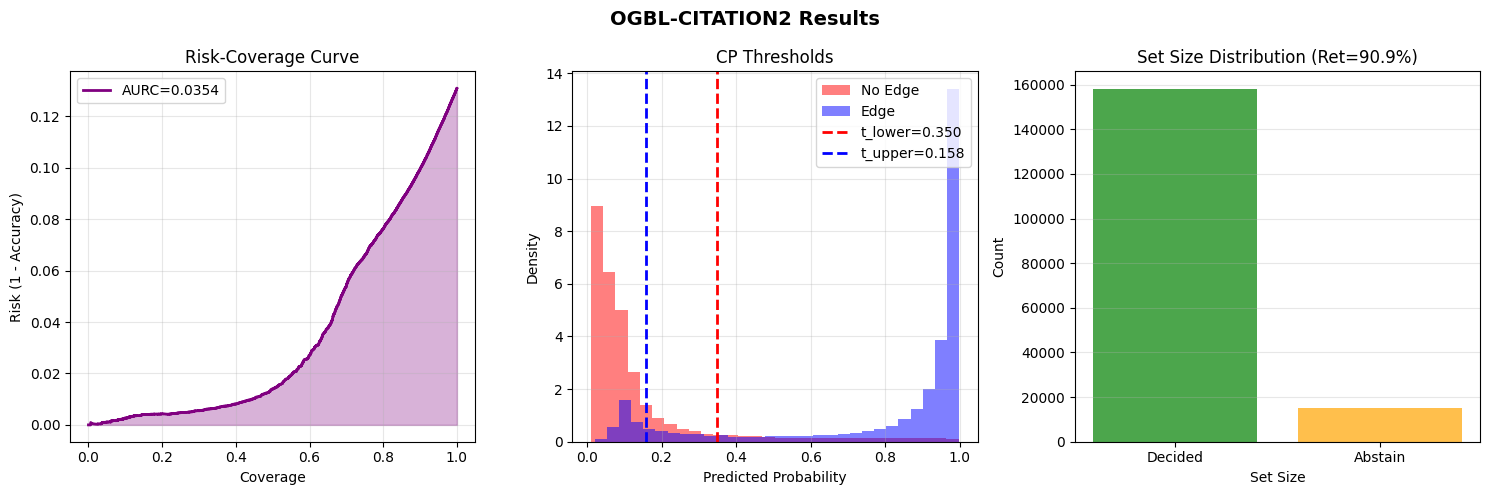

In [7]:
# Run the pipeline on ogbl-citation2
# Using sample_size=50000 for efficiency (the full dataset has millions of edges)
result = run_pipeline_ogb(
    adj=adj,
    split_edge=split_edge,
    name='ogbl-citation2',
    alpha=0.10,
    n_runs=10,
    n_components=32,
    sample_size=500000
)

## 4. Alpha Sweep Analysis

Analyze how coverage tracks the target $1 - \alpha$ across different confidence levels.

## 5. Summary

### Metrics Reported

| Metric | Purpose |
|--------|---------|
| **AUC** | Base scorer quality (threshold-free) |
| **AURC** | Selective prediction quality (lower is better) |
| **Coverage** | $P(y \in C(x))$ - main CP validity measure |
| **Avg Set Size** | Efficiency: near 1 = decided, near 2 = abstaining |
| **Retention** | Fraction with $|C(x)|=1$ (decided samples) |
| **Decided Accuracy** | Accuracy conditional on not abstaining |

### Dataset Characteristics

- **ogbl-citation2**: Large-scale academic citation network
- **Temporal split**: Training on older papers, testing on 2019 papers
- **Directed edges**: Citations are inherently directional (paper A cites paper B)

In [8]:
# Final summary
print("\n" + "="*60)
print("FINAL SUMMARY: ogbl-citation2")
print("="*60)

if 'result' in dir():
    means = result['means']
    print(f"\nMain Results (alpha=0.10):")
    print(f"  AUC             : {means['AUC']:.4f}")
    print(f"  AURC            : {means['AURC']:.4f}")
    print(f"  CP Coverage     : {means['CP Coverage']:.4f} (target: 0.90)")
    print(f"  CP Avg Set Size : {means['CP Avg Set Size']:.4f}")
    print(f"  CP Retention    : {means['CP Retention']:.4f}")
    print(f"  CP Decided Acc  : {means['CP Decided Acc']:.4f}")

print("\n--- Conclusions ---")
print("1. Directed SVD embeddings capture citation patterns effectively.")
print("2. CP achieves empirical coverage close to the target 1-alpha.")
print("3. High retention indicates CP decides most predictions confidently.")
print("4. Temporal split makes this a realistic evaluation scenario.")


FINAL SUMMARY: ogbl-citation2

Main Results (alpha=0.10):
  AUC             : 0.9439
  AURC            : 0.0353
  CP Coverage     : 0.9004 (target: 0.90)
  CP Avg Set Size : 1.0913
  CP Retention    : 0.9087
  CP Decided Acc  : 0.8904

--- Conclusions ---
1. Directed SVD embeddings capture citation patterns effectively.
2. CP achieves empirical coverage close to the target 1-alpha.
3. High retention indicates CP decides most predictions confidently.
4. Temporal split makes this a realistic evaluation scenario.
